# 04 — Revision analyses

Label-alignment, dual-metric scoring, scaling (14B), and full-precision checks for the R&R. Runs are read from `results/past_runs/<run_type>/`.

## 1. Setup

Loads the config, repo names, and ground-truth label map, and defines the plotting palette and `style()` helper used by every figure below. Run this first — everything else depends on it.

In [ ]:
import json, math, statistics
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import plotly.graph_objects as go
import yaml

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_cfg = yaml.safe_load(open(REPO_ROOT / "config.yaml"))
BENCHMARK_REPO = _cfg["compiled_dataset"]["repo_id"]
RESULTS_REPO = _cfg["results_repo"]["repo_id"]
prompt_version = _cfg.get("experiment", {}).get("prompt_version", "v1")
GROUND_TRUTH_TO_PIICODEX = json.load(open(REPO_ROOT / "config" / "pii_label_to_piicodex.json"))

CONDITIONS = ["zero_shot", "with_docs", "with_tools", "with_skills"]
CLABEL = {"zero_shot": "Zero-shot", "with_docs": "+Docs", "with_tools": "+Tool", "with_skills": "+Skills"}
INK, TEAL, TAUPE, SAGE = "#5C6B73", "#3D5A6C", "#9A8C7D", "#8B9E6B"

def style(fig, title="", h=420, w=720, **layout):
    base = dict(title=title, plot_bgcolor="#fafafa", height=h, width=w,
                legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
                margin=dict(t=44, b=72))
    base.update(layout)
    base.setdefault("yaxis", dict(gridcolor="#e0e0e0"))
    fig.update_layout(**base)
    
    return fig

## 2. Load runs

Defines `load_run`, which pulls any run's records from `results/past_runs/<run_type>/` (or the HuggingFace split), and loads the main run into `main`. This is the data every later section scores against.

In [2]:
def load_run(run_type, pv=None):
    """Records for a run: local past_runs first, else HF split <run_type>_<pv>. [] if absent."""
    pv = pv or prompt_version
    local = REPO_ROOT / "results" / "past_runs" / run_type / "experiment_results.json"
    if local.exists():
        return json.load(open(local))
    try:
        from datasets import load_dataset
        res = load_dataset(RESULTS_REPO, split=f"{run_type}_{pv}")
        bench = load_dataset(BENCHMARK_REPO, split="test")
        bench_by_id = {(row.get("id") or i): row for i, row in enumerate(bench)}
        out = []
        for r in res:
            b = bench_by_id.get(r["sample_id"], {})
            gt = b.get("pii_codex_ground_truth") or b.get("ground_truth") or []
            if isinstance(gt, str): gt = json.loads(gt) if gt else []
            if gt and isinstance(gt[0], str): gt = [{"type": t} for t in gt]
            preds = r.get("predictions"); preds = json.loads(preds) if isinstance(preds, str) else (preds or [])
            out.append({"sample_id": r["sample_id"], "source": r.get("source", ""), "model": r["model"],
                        "condition": r["condition"], "predictions": preds,
                        "ground_truth": gt if isinstance(gt, list) else [],
                        "tool_executed": bool(r.get("tool_executed"))})
        return out
    except Exception:
        return []

main = load_run("main")
print({m: sum(r["model"] == m for r in main) // 4 for m in sorted({r["model"] for r in main})}, "samples/condition")

{'gemma2_9b': 2000, 'llama3_8b': 2000, 'mistral_7b': 2000, 'qwen2_7b': 2000} samples/condition


## 3. Symmetric alignment + scoring

One map (ground-truth map + prediction aliases + the bridges below) applied identically to predictions and ground truth. Two metrics: type-only and span IoU≥0.5.

In [ ]:
PREDICTION_TO_PIICODEX = {
    # Identity (model outputs canonical PII Codex type name)
    "US_BANK_ACCOUNT_NUMBER": "US_BANK_ACCOUNT_NUMBER",
    "US_DRIVERS_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION": "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION",
    "NRP": "NRP",  # Nationality, religion, political (PII Codex PIIType)
    # Driver / license
    "DRIVER_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_DRIVER_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    "DRIVER'S_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    # SSN
    "SOCIAL_SECURITY_NUMBER": "US_SOCIAL_SECURITY_NUMBER",
    # Postal / zip
    "POSTAL_CODE": "ZIPCODE",
    "US_POSTAL_CODE": "ZIPCODE",
    # Location (COUNTRY_OF_ORIGIN -> LOCATION per paper Appendix A.2)
    "COUNTRY_OF_ORIGIN": "LOCATION",
    # Person / account
    "ACCOUNT_USERNAME": "PERSON",
    "SIBLING_NAME": "PERSON",
    "INDIVIDUAL": "PERSON",
    # Medical / health IDs (PII Codex: HEALTH_INSURANCE_ID)
    "MRN": "HEALTH_INSURANCE_ID",
    "MRN_NUMBER": "HEALTH_INSURANCE_ID",
    "PATIENT_ID": "HEALTH_INSURANCE_ID",
    "PATIENTID": "HEALTH_INSURANCE_ID",
    # ID document
    "ID_CARD_NUMBER": "US_PASSPORT_NUMBER",
    # Biometric (PII Codex: FINGERPRINT)
    "BIOM_IDENTIFIER": "FINGERPRINT",
    # Time
    "TIME_OF_DAY": "DATE_TIME",
    "SESSION_TIME": "DATE_TIME",
}

combined_label_map = {**GROUND_TRUTH_TO_PIICODEX, **PREDICTION_TO_PIICODEX}
ALIGNMENT_OVERRIDES = {
    "DATE": "DATE_TIME", "DATEOFBIRTH": "DATE_TIME", "DATETIME": "DATE_TIME", "DATE_AND_TIME": "DATE_TIME", "TIMESTAMP": "DATE_TIME",
    "ADDRESS": "LOCATION", "STREET": "LOCATION", "STREET_ADDRESS": "LOCATION", "STREET_NAME": "LOCATION",
    "BUILDING": "LOCATION", "BUILDING_NUMBER": "LOCATION", "SECONDARY_ADDRESS": "LOCATION", "SECADDRESS": "LOCATION",
    "UK_NHS": "HEALTH_INSURANCE_ID", "MEDICALRECORDNUMBER": "HEALTH_INSURANCE_ID",
    "GENDER": "GENDER", "IPV4_ADDRESS": "IP_ADDRESS", "IPV6_ADDRESS": "IP_ADDRESS",
    "ZIP_CODE": "ZIPCODE", "ZIP": "ZIPCODE", "POSTALCODE": "ZIPCODE",
    "SOCIALSECURITYNUMBER": "US_SOCIAL_SECURITY_NUMBER", "SOCIAL_NUMBER": "US_SOCIAL_SECURITY_NUMBER",
    "PASSPORTNUMBER": "US_PASSPORT_NUMBER", "TELEPHONE_NUMBER": "PHONE_NUMBER",
}
CANONICAL_ALIAS = {**combined_label_map, **ALIGNMENT_OVERRIDES}
import re as _re

def _key(t): return t.upper().replace("-", "_").replace(" ", "_") if t else ""

def _fallback(k):
    if _re.search(r"IPV?4|IPV?6|IP_?ADDR", k): return "IP_ADDRESS"
    if "ZIP" in k or "POSTAL" in k: return "ZIPCODE"
    if "SSN" in k or "SOCIAL_SEC" in k or "SOCIALSEC" in k: return "US_SOCIAL_SECURITY_NUMBER"
    if "PASSPORT" in k: return "US_PASSPORT_NUMBER"
    if "DRIVER" in k and "LICEN" in k: return "US_DRIVERS_LICENSE_NUMBER"
    if k.startswith("DATE") or k.endswith("DATE") or "BIRTH" in k or k in ("TIME",) or "TIMESTAMP" in k: return "DATE_TIME"
    if "EMAIL" in k: return "EMAIL_ADDRESS"
    if "PHONE" in k or "TELEPHONE" in k or k in ("TEL", "MOBILE", "FAX"): return "PHONE_NUMBER"
    if "ADDRESS" in k or k in ("CITY", "STATE", "COUNTRY", "COUNTY", "STREET"): return "LOCATION"
    
    return None

def norm(t):
    k = _key(t)
    if not k: return "UNKNOWN"
    if k in CANONICAL_ALIAS:
        v = CANONICAL_ALIAS[k]; return v if v is not None else "UNKNOWN"
    
    return _fallback(k) or k

def norm_pre(t):  # asymmetric §3.2 map, for the before/after contrast
    k = _key(t); v = combined_label_map.get(k, k)
    
    return v if v is not None else "UNKNOWN"

def _sint(d, k):
    v = d.get(k, 0)
    
    return v if isinstance(v, int) else (int(v) if str(v).lstrip("-").isdigit() else 0)

def _iou(a, b):
    s1, e1, s2, e2 = _sint(a,"start"), _sint(a,"end"), _sint(b,"start"), _sint(b,"end")
    inter = max(0, min(e1, e2) - max(s1, s2)); u = (e1-s1) + (e2-s2) - inter
    
    return inter / u if u > 0 else 0.0

def f1(preds, gt, nf, span):
    vp = [p for p in preds if isinstance(p, dict) and "type" in p]
    if not gt: return 1.0 if not vp else 0.0
    if not vp: return 0.0
    used, tp = set(), 0
    
    for p in vp:
        pt = nf(p.get("type", ""))
        for i, t in enumerate(gt):
            if i in used or pt != nf(t.get("type", "")): continue
            if span and (_sint(t,"start") or _sint(t,"end")) and _iou(p, t) < 0.5: continue
            used.add(i); tp += 1; break
    
    pr, rc = tp/len(vp), tp/len(gt)
    
    return 2*pr*rc/(pr+rc) if (pr+rc) else 0.0

def mean_f1(recs, cond, nf, span):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], nf, span) for r in recs if r["condition"] == cond]
    
    return sum(v)/len(v) if v else float("nan")

## 4. Dual-metric F1 (before vs after alignment)

Builds the before-vs-after, type-vs-span F1 table and the headline figure, showing that symmetric alignment narrows the gap at the type level and inverts it at the span level.

In [ ]:
rows = []
for span in (False, True):
    for nf, tag in [(norm_pre, "before"), (norm, "after")]:
        row = {"metric": "span" if span else "type", "align": tag}
        for c in CONDITIONS: row[CLABEL[c]] = round(mean_f1(main, c, nf, span), 3)
        row["ZS−Tool"] = round(row["Zero-shot"] - row["+Tool"], 3)
        rows.append(row)

df_dual = pd.DataFrame(rows)

df_dual

,metric,align,Zero-shot,+Docs,+Tool,+Skills,ZS−Tool
0,type,before,0.572,0.526,0.403,0.390,0.169
1,type,after,0.631,0.602,0.527,0.511,0.104
2,span,before,0.299,0.256,0.339,0.333,-0.040
3,span,after,0.325,0.301,0.455,0.448,-0.130


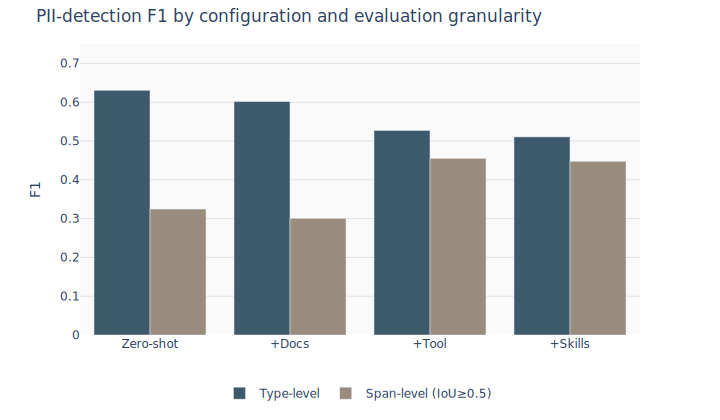

In [ ]:
# Post-alignment F1 by condition under each metric: zero-shot leads on type, the detector leads on span.
fig = go.Figure()
fig.add_bar(name="Type-level", x=[CLABEL[c] for c in CONDITIONS], y=[mean_f1(main, c, norm, False) for c in CONDITIONS], marker_color=TEAL)
fig.add_bar(name="Span-level (IoU≥0.5)", x=[CLABEL[c] for c in CONDITIONS], y=[mean_f1(main, c, norm, True) for c in CONDITIONS], marker_color=TAUPE)
style(fig, "PII-detection F1 by configuration and evaluation granularity", barmode="group",
      yaxis=dict(title="F1", range=[0, 0.75], gridcolor="#e0e0e0"))

fig.show(renderer="svg"); fig.write_image("fig_dual_metric_main.pdf")

## 5. Per-type recall (tool/skill), before vs after alignment

Computes tool/skill recall per PII type, before vs after alignment, separating the collapses that were label-schema artifacts (DATE_TIME, LOCATION) from the genuine detector limit (HEALTH_INSURANCE_ID).

In [ ]:
def type_recall(nf, group, conds, min_n=50):
    hit, tot = defaultdict(int), defaultdict(int)
    
    for r in main:
        if r["condition"] not in conds: continue
        gt = r["ground_truth"] or []; used = set()
        
        for p in [p for p in (r["predictions"] or []) if isinstance(p, dict) and "type" in p]:
            pt = nf(p.get("type", ""))
            
            for i, t in enumerate(gt):
                if i in used or pt != nf(t.get("type", "")): continue
                used.add(i); break
        
        for i, t in enumerate(gt):
            k = group(t.get("type", "")); tot[k] += 1
            if i in used: hit[k] += 1
    
    return {k: hit[k]/tot[k] for k in tot if tot[k] >= min_n}

aug = ["with_tools", "with_skills"]
b, a = type_recall(norm_pre, norm, aug), type_recall(norm, norm, aug)
df_type = pd.DataFrame([{"type": t, "before": round(b.get(t, 0), 3), "after": round(a.get(t, 0), 3),
                         "Δ": round(a.get(t, 0) - b.get(t, 0), 3)}
                        for t in sorted(set(b) | set(a), key=lambda t: -a.get(t, 0))])

df_type

,type,before,after,Δ
0,EMAIL_ADDRESS,0.968,0.968,0.000
1,MAC_ADDRESS,0.955,0.955,0.000
2,IP_ADDRESS,0.939,0.939,0.000
3,URL,0.777,0.777,0.000
4,US_DRIVERS_LICENSE_NUMBER,0.760,0.760,0.000
5,DATE_TIME,0.217,0.690,0.473
6,PHONE_NUMBER,0.640,0.640,0.000
7,US_PASSPORT_NUMBER,0.635,0.635,0.000
8,US_SOCIAL_SECURITY_NUMBER,0.553,0.553,0.000
9,US_BANK_ACCOUNT_NUMBER,0.477,0.477,0.000


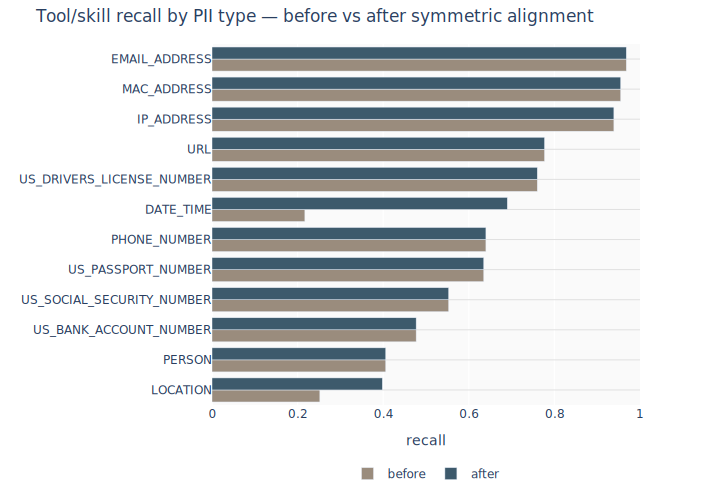

In [ ]:
top = df_type.head(12).iloc[::-1]

fig = go.Figure()
fig.add_bar(name="before", y=top["type"], x=top["before"], orientation="h", marker_color=TAUPE)
fig.add_bar(name="after", y=top["type"], x=top["after"], orientation="h", marker_color=TEAL)
style(fig, "Tool/skill recall by PII type — before vs after symmetric alignment", h=500,
      barmode="group", xaxis=dict(title="recall", range=[0, 1]))

fig.show(renderer="svg"); fig.write_image("fig_type_recall_alignment.pdf")

## 6. Detector over-prediction

Tallies how often the detector predicts each type versus its true frequency, surfacing the over-generation (drivers-license, bank-account, URL) that drives the precision collapse under tool use.

In [ ]:
pv, sup, seen = Counter(), Counter(), set()
for r in main:
    if r["condition"] in aug:
        for p in (r["predictions"] or []):
            if isinstance(p, dict) and "type" in p: pv[norm(p.get("type", ""))] += 1
    if r["sample_id"] not in seen:
        seen.add(r["sample_id"])
        for t in (r["ground_truth"] or []): sup[norm(t.get("type", ""))] += 1
df_over = pd.DataFrame([{"type": k, "predicted": n, "support": sup.get(k, 0),
                         "ratio": round(n / sup[k], 1) if sup.get(k) else float("inf")}
                        for k, n in pv.most_common()]).head(12)

df_over

,type,predicted,support,ratio
0,DATE_TIME,16097,2103,7.7
1,US_DRIVERS_LICENSE_NUMBER,12150,383,31.7
2,PERSON,10435,2324,4.5
3,LOCATION,7461,1930,3.9
4,PHONE_NUMBER,5771,566,10.2
5,EMAIL_ADDRESS,5080,632,8.0
6,US_SOCIAL_SECURITY_NUMBER,4863,632,7.7
7,URL,4501,92,48.9
8,IP_ADDRESS,4051,515,7.9
9,US_BANK_ACCOUNT_NUMBER,3421,44,77.8


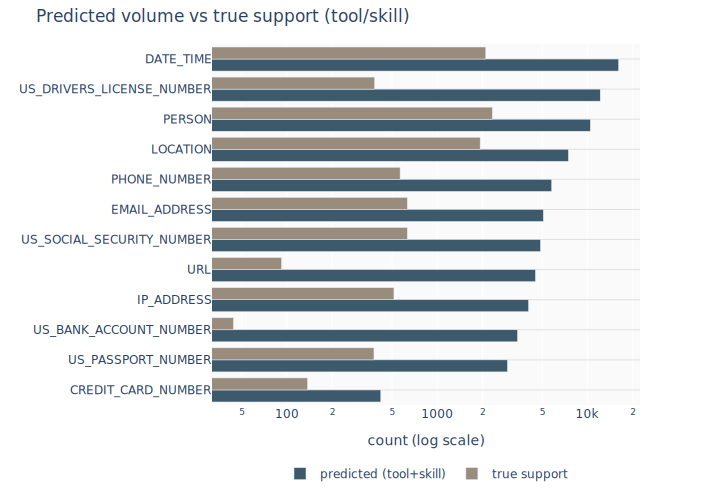

In [ ]:
o = df_over.iloc[::-1]

fig = go.Figure()
fig.add_bar(name="predicted (tool+skill)", y=o["type"], x=o["predicted"], orientation="h", marker_color=TEAL)
fig.add_bar(name="true support", y=o["type"], x=o["support"], orientation="h", marker_color=TAUPE)

style(fig, "Predicted volume vs true support (tool/skill)", h=500,
      barmode="group", xaxis=dict(title="count (log scale)", type="log"))

fig.show(renderer="svg"); fig.write_image("fig_overprediction.pdf")

## 7. Scaling — Qwen2.5-14B

Loads the 14B run and slots it into the dual-metric table beside the 7–9B models, showing the augmentation pattern is unchanged with scale.

,set,Zero-shot,+Docs,+Tool,+Skills
0,7–9B avg,0.631,0.602,0.527,0.511
1,Qwen 14B,0.605,0.632,0.520,0.521


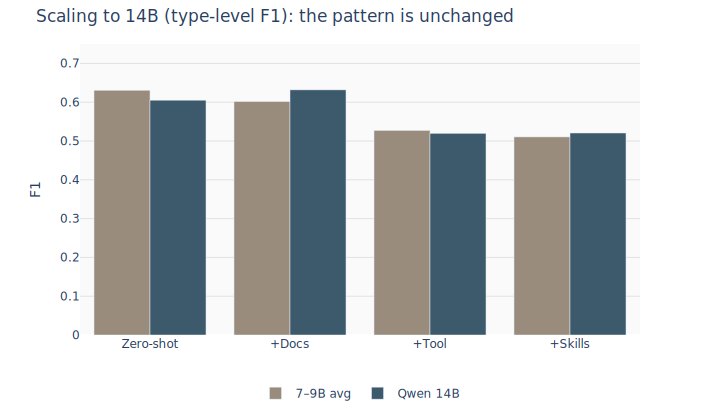

In [ ]:
scaling = load_run("scaling")
if not scaling:
    print("scaling run not found")
else:
    sevenb = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    
    def cond_means(recs, models, span=False):
        return {c: statistics.mean([f1(r["predictions"] or [], r["ground_truth"] or [], norm, span)
                                    for r in recs if r["condition"] == c and r["model"] in models]) for c in CONDITIONS}
    
    avg = cond_means(main, sevenb); q14 = cond_means(scaling, ["qwen2_14b"])
    display(pd.DataFrame([{"set": "7–9B avg", **{CLABEL[c]: round(avg[c], 3) for c in CONDITIONS}},
                          {"set": "Qwen 14B", **{CLABEL[c]: round(q14[c], 3) for c in CONDITIONS}}]))
    fig = go.Figure()
    fig.add_bar(name="7–9B avg", x=[CLABEL[c] for c in CONDITIONS], y=[avg[c] for c in CONDITIONS], marker_color=TAUPE)
    fig.add_bar(name="Qwen 14B", x=[CLABEL[c] for c in CONDITIONS], y=[q14[c] for c in CONDITIONS], marker_color=TEAL)
    style(fig, "Scaling to 14B (type-level F1): the pattern is unchanged", barmode="group",
          yaxis=dict(title="F1", range=[0, 0.75], gridcolor="#e0e0e0"))
    
    fig.show(renderer="svg"); fig.write_image("fig_scaling_14b.pdf")

## 8. Full precision vs 4-bit

Four models re-run at fp16/bf16 on a 300-sample subset, compared **paired** against 4-bit on the identical IDs. Tests whether quantization drives the effect.

,model,4-bit,fp16,Δ,95% CI
0,Gemma 2 9B,0.567,0.574,0.007,±0.008
1,Llama 3.1 8B,0.562,0.590,0.028,±0.016
2,Mistral 7B,0.530,0.527,-0.003,±0.012
3,Qwen 2.5 7B,0.565,0.557,-0.008,±0.012


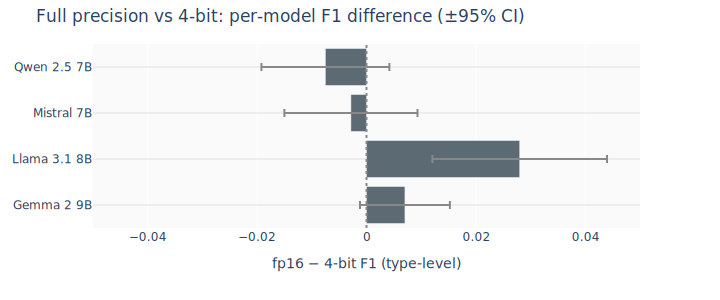

In [20]:
fp16 = load_run("fp16")
if not fp16:
    print("fp16 run not found")
else:
    main_ix = {(r["model"], r["condition"], r["sample_id"]): r for r in main}
    models = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    MLABEL = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B", "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}
    
    rows, deltas, cis = [], [], []
    for m in models:
        d = []
        q4 = qf = 0; n = 0
        for x in fp16:
            if x["model"] != m: continue
            mr = main_ix.get((m, x["condition"], x["sample_id"]))
            if mr is None: continue
            ff = f1(x["predictions"] or [], x["ground_truth"] or [], norm, False)
            qq = f1(mr["predictions"] or [], mr["ground_truth"] or [], norm, False)
            d.append(ff - qq); qf += ff; q4 += qq; n += 1
        md_, sd = statistics.mean(d), statistics.pstdev(d)
        ci = 1.96 * sd / math.sqrt(len(d))
        rows.append({"model": MLABEL[m], "4-bit": round(q4/n, 3), "fp16": round(qf/n, 3), "Δ": round(md_, 3), "95% CI": f"±{ci:.3f}"})
        deltas.append(md_); cis.append(ci)
    
    display(pd.DataFrame(rows))
    fig = go.Figure(go.Bar(y=[MLABEL[m] for m in models], x=deltas, orientation="h",
                           error_x=dict(type="data", array=cis, color="#888"), marker_color=INK))
    
    fig.add_vline(x=0, line_dash="dot", line_color="#888")
    style(fig, "Full precision vs 4-bit: per-model F1 difference (±95% CI)", h=300,
          xaxis=dict(title="fp16 − 4-bit F1 (type-level)", range=[-0.05, 0.05], zeroline=False))
    
    fig.update_layout(showlegend=False)
    fig.show(renderer="svg"); fig.write_image("fig_fp16_vs_4bit.pdf")

## 9. Significance, reliability, and determinism

Paired t-test and Cohen's d on post-alignment type-only F1 (each condition vs zero-shot); tool-call execution rate and turn counts; and the determinism that makes a seed sweep unnecessary.

Decoding is greedy (`do_sample=False`; MLX argmax), so outputs are deterministic across seeds — run-to-run variance is nil and the seed governs only the fixed benchmark subsample.

In [ ]:
from scipy import stats as _st
def _ps(m, c):
    return {r["sample_id"]: f1(r["predictions"] or [], r["ground_truth"] or [], norm, False)
            for r in main if r["model"] == m and r["condition"] == c}

rows = []

for m in ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]:
    zs = _ps(m, "zero_shot")
    for c in ["with_docs", "with_tools", "with_skills"]:
        cc = _ps(m, c); ids = sorted(set(zs) & set(cc))
        a, b = [cc[i] for i in ids], [zs[i] for i in ids]
        d = [x - y for x, y in zip(a, b)]
        t, p = _st.ttest_rel(a, b)
        rows.append({"model": m, "vs ZS": CLABEL[c], "ΔF1": round(statistics.mean(d), 3),
                     "Cohen d": round(statistics.mean(d) / (statistics.pstdev(d) or 1e-9), 2),
                     "p": f"{p:.1e}"})

df_sig = pd.DataFrame(rows)
df_sig

,model,vs ZS,ΔF1,Cohen d,p
0,gemma2_9b,+Docs,0.011,0.04,7.1e-02
1,gemma2_9b,+Tool,-0.099,-0.27,6.1e-32
2,gemma2_9b,+Skills,-0.098,-0.27,1.8e-31
3,llama3_8b,+Docs,-0.149,-0.37,2.1e-57
4,llama3_8b,+Tool,-0.108,-0.32,4.7e-44
5,llama3_8b,+Skills,-0.172,-0.49,5.3e-95
6,mistral_7b,+Docs,0.009,0.03,1.8e-01
7,mistral_7b,+Tool,-0.056,-0.16,2.0e-12
8,mistral_7b,+Skills,-0.056,-0.16,1.3e-12
9,qwen2_7b,+Docs,0.012,0.04,9.2e-02


In [ ]:
rows = []
for c in ["with_tools", "with_skills"]:
    for m in ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]:
        rs = [r for r in main if r["model"] == m and r["condition"] == c]
        fired = sum(1 for r in rs if r.get("tool_executed"))
        turns = [r.get("conversation_turns") or 1 for r in rs]
        rows.append({"condition": CLABEL[c], "model": m, "tool fired": f"{fired}/{len(rs)}",
                     "%": round(100 * fired / len(rs), 1), "mean turns": round(statistics.mean(turns), 2)})

df_reliab = pd.DataFrame(rows)
df_reliab

,condition,model,tool fired,%,mean turns
0,+Tool,gemma2_9b,2000/2000,100.0,2.00
1,+Tool,llama3_8b,2000/2000,100.0,2.01
2,+Tool,mistral_7b,1999/2000,100.0,2.00
3,+Tool,qwen2_7b,2000/2000,100.0,2.01
4,+Skills,gemma2_9b,2000/2000,100.0,3.99
5,+Skills,llama3_8b,2000/2000,100.0,3.95
6,+Skills,mistral_7b,1999/2000,100.0,2.02
7,+Skills,qwen2_7b,2000/2000,100.0,2.38


## 10. Specialized-detector baseline

PII-Codex/Presidio run standalone on the 2,000 texts (no LLM), scored with the same alignment — the prior-work detector row to judge the four configurations against. Requires `data/samples_main.json` (`make rr-samples`) and the `pii_codex` package. Running it also writes the detector predictions to `results/past_runs/detector/`, so the baseline is reproducible via `load_run("detector")` without re-running PII-Codex.


In [21]:
# PII-Codex/Presidio standalone on the 2,000 texts (no LLM), scored with the same alignment.
import sys
sys.path.insert(0, str(REPO_ROOT / "lib"))
samples = json.load(open(REPO_ROOT / "data" / "samples_main.json"))

try:
    from pii_codex.services.analysis_service import PIIAnalysisService
    from ablation_harness.tools.registry import ToolRegistry, PiiCodexTool
    
    reg = ToolRegistry(); reg.register(PiiCodexTool(PIIAnalysisService()))
    det = []
    
    for s in samples:
        res = reg.execute("analyze_pii", text=s["text"])
        preds = res.get("detections", []) if isinstance(res, dict) else (res or [])
        gt = s.get("ground_truth"); gt = json.loads(gt) if isinstance(gt, str) else (gt or [])
        det.append({"predictions": preds, "ground_truth": gt})
    base = {lbl: round(sum(f1(r["predictions"], r["ground_truth"], norm, span) for r in det) / len(det), 3)
            for span, lbl in [(False, "type-only"), (True, "span-IoU")]}
    
    print("Specialized detector (PII-Codex standalone) F1:", base)
    print("Compare against the configurations in section 4.")
    
    # Persist as a run file so the detector baseline is reproducible from an artifact (load_run("detector")).
    det_dir = REPO_ROOT / "results" / "past_runs" / "detector"
    det_dir.mkdir(parents=True, exist_ok=True)
    
    records = [
        {"sample_id": s["id"], "source": s.get("source", ""), "model": "pii_codex",
         "condition": "detector", "predictions": r["predictions"], "ground_truth": r["ground_truth"],
         "tool_executed": True}
        for s, r in zip(samples, det)
    ]
    json.dump(records, open(det_dir / "experiment_results.json", "w"))
    
    print(f"Saved {len(records)} detector rows -> {det_dir / 'experiment_results.json'}")
except ImportError as e:
    print(f"pii_codex not installed — run `make install`. ({e})")
except FileNotFoundError:
    print("data/samples_main.json missing — run `make rr-samples` first.")

Specialized detector (PII-Codex standalone) F1: {'type-only': 0.276, 'span-IoU': 0.227}
Compare against the configurations in section 4.
Saved 2000 detector rows -> /Users/erosado/work/academia/pii-codex-skills-ablation-study/results/past_runs/detector/experiment_results.json


## 11. Few-shot and chain-of-thought baselines

Loads the `baselines` run (conditions `few_shot`, `cot`; four models, full 2,000) and scores them
under the symmetric alignment, next to zero-shot. Tests whether the cheapest — prompt-only,
parametric — augmentations behave differently from external tool/skill scaffolding (reviewer 2 #6).
No-ops until `make rr-baselines` has been run.

In [22]:
baselines = load_run("baselines")
if not baselines:
    print("baselines run not found — run `make rr-baselines`, then re-run this cell.")
else:
    models = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    MLAB = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B", "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}
    
    def mc(recs, m, c, span):
        v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, span)
             for r in recs if r["model"] == m and r["condition"] == c]
        return sum(v) / len(v) if v else float("nan")
    
    rows = []
    for m in models:
        rows.append({"model": MLAB[m],
                     "ZS": round(mc(main, m, "zero_shot", False), 3),
                     "few-shot": round(mc(baselines, m, "few_shot", False), 3),
                     "CoT": round(mc(baselines, m, "cot", False), 3),
                     "ZS (span)": round(mc(main, m, "zero_shot", True), 3),
                     "few-shot (span)": round(mc(baselines, m, "few_shot", True), 3),
                     "CoT (span)": round(mc(baselines, m, "cot", True), 3)})
    display(pd.DataFrame(rows))

    print("\n4-model averages (paste into Results / abstract):")

    for span, lbl in [(False, "type-only"), (True, "span")]:
        zs = sum(mc(main, m, "zero_shot", span) for m in models) / 4
        fs = sum(mc(baselines, m, "few_shot", span) for m in models) / 4
        ct = sum(mc(baselines, m, "cot", span) for m in models) / 4
        print(f"  {lbl:9}: ZS {zs:.3f} | few-shot {fs:.3f} | CoT {ct:.3f}")

,model,ZS,few-shot,CoT,ZS (span),few-shot (span),CoT (span)
0,Gemma 2 9B,0.624,0.647,0.674,0.328,0.338,0.333
1,Llama 3.1 8B,0.675,0.610,0.573,0.338,0.303,0.274
2,Mistral 7B,0.584,0.616,0.566,0.305,0.312,0.295
3,Qwen 2.5 7B,0.640,0.640,0.609,0.328,0.324,0.291



4-model averages (paste into Results / abstract):
  type-only: ZS 0.631 | few-shot 0.628 | CoT 0.606
  span     : ZS 0.325 | few-shot 0.319 | CoT 0.298


## 12. All configurations at a glance

One bar per configuration (type-level F1, four-model average), grouped by family. Shows the parametric configurations (zero-shot, few-shot, CoT, +Docs) clustering near the top, the tool-augmented conditions dropping below the zero-shot reference line, and the standalone library far beneath both.

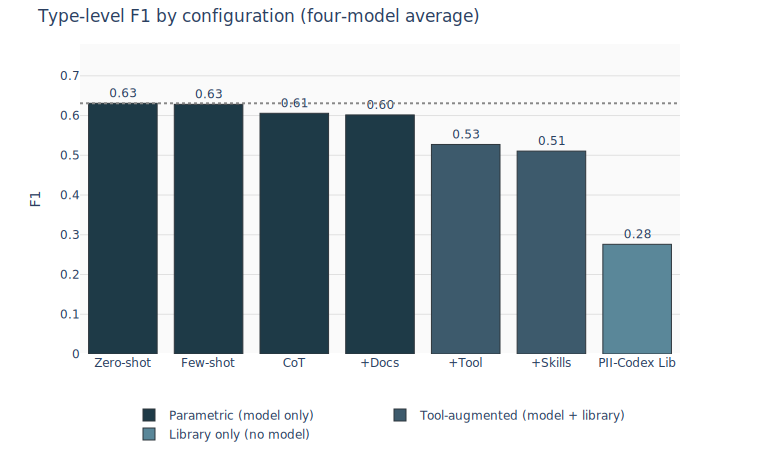

In [23]:
# Type-level F1 (4-model average) for every configuration, grouped by family.
def _avg(recs, cond):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, False)
         for r in recs if r["condition"] == cond]
    return sum(v) / len(v) if v else None

bars = [
    ("Zero-shot", _avg(main, "zero_shot"),               "Parametric (model only)"),
    ("Few-shot",  _avg(baselines, "few_shot") if baselines else None, "Parametric (model only)"),
    ("CoT",       _avg(baselines, "cot") if baselines else None,      "Parametric (model only)"),
    ("+Docs",     _avg(main, "with_docs"),               "Parametric (model only)"),
    ("+Tool",     _avg(main, "with_tools"),              "Tool-augmented (model + library)"),
    ("+Skills",   _avg(main, "with_skills"),             "Tool-augmented (model + library)"),
]
# detector-only value from Section 10 if available, else the recorded result
try:
    bars.append(("PII-Codex Lib", base["type-only"], "Library only (no model)"))
except NameError:
    bars.append(("PII-Codex Lib", 0.28, "Library only (no model)"))

bars = [b for b in bars if b[1] is not None]
bars.sort(key=lambda b: -b[1])
order = [b[0] for b in bars]
fam_color = {
    "Parametric (model only)":          "#1E3A47",  # very dark teal (best)
    "Tool-augmented (model + library)": "#3D5A6C",  # deep teal
    "Library only (no model)":          "#5A8799",  # medium teal (lowest)
}
zs = next(b[1] for b in bars if b[0] == "Zero-shot")

fig = go.Figure()
for fam, col in fam_color.items():
    xs = [b[0] for b in bars if b[2] == fam]
    ys = [b[1] for b in bars if b[2] == fam]
    fig.add_bar(name=fam, x=xs, y=ys, marker_color=col, marker_line=dict(width=1, color="#2D353B"),
                text=[f"{y:.2f}" for y in ys], textposition="outside", cliponaxis=False)
fig.update_xaxes(categoryorder="array", categoryarray=order)
fig.add_hline(y=zs, line_dash="dot", line_color="#888")
style(fig, "Type-level F1 by configuration (four-model average)", h=460, w=760,
      barmode="group", yaxis=dict(title="F1", range=[0, 0.78], gridcolor="#e0e0e0"))
fig.show(renderer="svg"); fig.write_image("fig_all_conditions.pdf")